# 05. Градиентный бустинг с нуля за 30 строк — и точное совпадение с scikit-learn

| | |
|---|---|
| **Уровень** | 2 из 4 — маленькие данные: реальные наборы и базовые приёмы (`2_small`) |
| **Скрипт-источник** | [`05_gbm_from_scratch.py`](../05_gbm_from_scratch.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 2 с |

**Цель.** Написать рабочий бустинг самостоятельно и убедиться, что библиотека делает то же самое.

### Чему вы научитесь

- Класс бустинга: старт, цикл по деревьям, псевдо-остатки, шаг ν, прогноз
- Деревья scikit-learn как «слабые модели»
- Проверка реализации сравнением с эталоном до 1e-12

### Данные

500 точек, y = `sin(x)` + 0.3x + шум (σ = 0.3), x ∈ [0, 10] — синтетика, чтобы видеть модель глазами.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Реализация: весь алгоритм в одном классе
3. **Этап 3.** Обучение и проверка на отложенных 30%
4. **Этап 4.** Сверка с sklearn.GradientBoostingRegressor (те же параметры)
5. **Этап 5.** Картинка: модель после 1, 10 и 100 деревьев

> Ноутбук собран из `examples/2_small/05_gbm_from_scratch.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "2_small/05_gbm_from_scratch.py", title="05. Градиентный бустинг с нуля за 30 строк",
             goal="написать бустинг и совпасть с sklearn.GradientBoostingRegressor")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

## Этап 1. Данные

In [2]:
rng = np.random.default_rng(5)
n = ex.size(500, 200)
x = np.sort(rng.uniform(0, 10, n))
y = np.sin(x) + 0.3 * x + rng.normal(0, 0.3, n)
X = x[:, None]
idx = rng.permutation(n)
tr, te = idx[: int(0.7 * n)], idx[int(0.7 * n):]
ex.describe(X, y, names=["x"], target="y", source="синтетика: sin(x) + 0.3x + N(0, 0.3²)")

   Источник: синтетика: sin(x) + 0.3x + N(0, 0.3²)
   Объектов: 500   признаков: 1   память: 0.00 МБ
   Типы признаков: float64 × 1
   Пропусков нет
   Цель «y»: среднее 1.613, σ 1.110, мин -0.637, макс 4.158
   Первые строки:


,x,[y]
0,0.000014,-0.442148
1,0.009198,-0.466928
2,0.011997,0.200468


## Этап 2. Реализация: весь алгоритм в одном классе

In [3]:
class MyGBM:
    """Градиентный бустинг для квадратичной потери."""

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth

    def fit(self, X, y):
        self.f0 = y.mean()                              # 1. старт: лучшая константа
        F = np.full(len(y), self.f0)
        self.trees = []
        for m in range(self.n_estimators):
            r = y - F                                   # 2. псевдо-остатки = антиградиент ½(y − F)²
            tree = DecisionTreeRegressor(max_depth=self.max_depth, criterion="squared_error", random_state=m)
            tree.fit(X, r)                              # 3. дерево приближает остатки
            F += self.learning_rate * tree.predict(X)   # 4. маленький шаг
            self.trees.append(tree)
        return self

    def predict(self, X):
        return self.f0 + self.learning_rate * sum(t.predict(X) for t in self.trees)


print("   MyGBM: старт → цикл (остатки → дерево → шаг ν) → прогноз = F₀ + ν·Σ деревьев")

   MyGBM: старт → цикл (остатки → дерево → шаг ν) → прогноз = F₀ + ν·Σ деревьев


## Этап 3. Обучение и проверка на отложенных 30%

In [4]:
with ex.timer("обучение 100 деревьев"):
    my = MyGBM().fit(X[tr], y[tr])
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
print(f"   RMSE: константа {rmse(y[te], y[tr].mean()):.3f}, MyGBM {rmse(y[te], my.predict(X[te])):.3f} (шум σ = 0.3)")
assert rmse(y[te], my.predict(X[te])) < 0.4

   ⏱ обучение 100 деревьев: 0.05 с
   RMSE: константа 1.080, MyGBM 0.309 (шум σ = 0.3)


## Этап 4. Сверка с sklearn.GradientBoostingRegressor (те же параметры)

In [5]:
sk = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0).fit(X[tr], y[tr])
diff = np.abs(sk.predict(X[te]) - my.predict(X[te])).max()
print(f"   наибольшее расхождение прогнозов: {diff:.1e}")
assert diff < 1e-10
ex.note("30 строк повторяют промышленную реализацию. Остальное в библиотеках — скорость, удобство и регуляризация.")

   наибольшее расхождение прогнозов: 3.1e-15


> ▸ **Вывод.** 30 строк повторяют промышленную реализацию. Остальное в библиотеках — скорость, удобство и регуляризация.

## Этап 5. Картинка: модель после 1, 10 и 100 деревьев

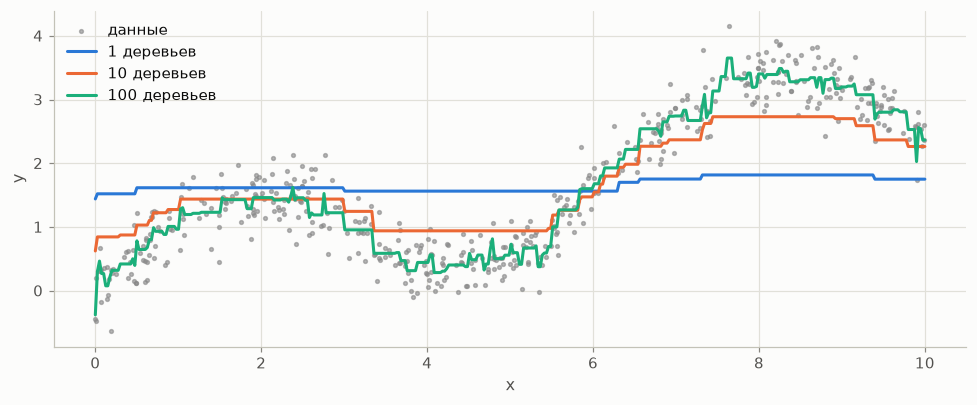

Готово за 1.1 с


In [6]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.scatter(x, y, s=6, color="#888", alpha=0.6, label="данные")
g = np.linspace(0, 10, 400)[:, None]
for k in (1, 10, 100):
    ax.plot(g[:, 0], my.f0 + my.learning_rate * sum(t.predict(g) for t in my.trees[:k]), lw=2, label=f"{k} деревьев")
ax.set(xlabel="x", ylabel="y")
ax.legend()
fig.tight_layout()
ex.finish(fig, "05_gbm_from_scratch")
ex.done()

## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Добавьте в MyGBM подвыборку строк (subsample = 0.5): почему точного совпадения с sklearn больше нет?
2. Замените квадратичные потери абсолютными: псевдо-остаток `sign(y − F)`, значение листа — медиана остатков.
3. Добавьте раннюю остановку по отложенной выборке и сравните число деревьев.

## Что дальше

- **Теория в курсе:** [4.3 «Бустинг с нуля»](../../../lessons/lesson_4_3/README.md).
- **Предыдущий пример:** [04. Темп обучения на 20 точках: быстро и переобученно или медленно и точно](../../1_tiny/notebooks/04_learning_rate_by_hand.ipynb)
- **Следующий пример:** [06. Реальные данные «Диабет» (442 пациента): бустинг против простых моделей](06_diabetes_regression.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)